In [1]:
import geopandas as gpd
import pandas as pd

# Load the shapefile (just point to the .shp file)
gdf = gpd.read_file("../data/input_viabel/Wegsectieonderdeel_SPLIT.shp")

# Now it's a GeoDataFrame — works like pandas but with spatial features
print(gdf.head())       # View first few rows
print(gdf.columns)      # View column names
print(gdf.crs)          # Check coordinate reference system
print(gdf.geometry)     # Access the geometries (points, lines, polygons)

    G_staat      G_date   S_index      S_date WSO_id   V_index Dofunctie  \
0  0.808994  01/01/1950  0.860432  01/01/1950      0  0.757556        RW   
1  0.871160  01/01/1950  0.872750  01/01/1950      1  0.869571        RW   
2  0.900000  01/01/1950  0.900000  01/01/1950      2  0.900000        RW   
3  0.769092  01/01/1950  0.769092  01/01/1950      3  0.769092        RW   
4  0.757765  01/01/1950  0.773281  01/01/1950      4  0.742248        RW   

  Verharding Wegfunctie                 Straat  Gemeente  \
0         BP        ERF  OUDE HAACHTSESTEENWEG  Machelen   
1         BP        ERF          REGIMENTSBERG  Machelen   
2         BP         VW      KONING ALBERTLAAN  Machelen   
3         BP        ERF   SINT-KORNELIUSSTRAAT  Machelen   
4         BS        ERF  LEONARDO DA VINCILAAN  Machelen   

                              Wegsectie                                  Guid  \
0  9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1  9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1   
1  622061DD-EA4C-474

<Axes: >

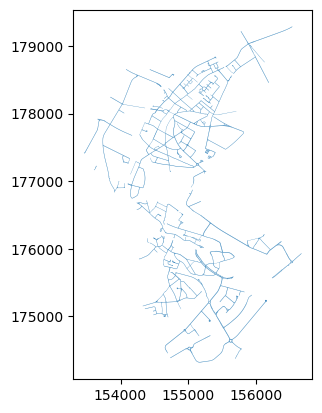

In [2]:
gdf.plot()

In [3]:
print(gdf.columns)
print(gdf.G_date.value_counts())
gdf.shape

Index(['G_staat', 'G_date', 'S_index', 'S_date', 'WSO_id', 'V_index',
       'Dofunctie', 'Verharding', 'Wegfunctie', 'Straat', 'Gemeente',
       'Wegsectie', 'Guid', 'Oppervlakt', 'Prioriteit', 'DATUM', 'geometry'],
      dtype='object')
G_date
01/01/1950    1090
Name: count, dtype: int64


(1090, 17)

In [4]:
print(gdf.geometry.geom_type.value_counts())
gdf.info()

Polygon    1090
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   G_staat     1090 non-null   float64 
 1   G_date      1090 non-null   object  
 2   S_index     1090 non-null   float64 
 3   S_date      1090 non-null   object  
 4   WSO_id      1090 non-null   object  
 5   V_index     1090 non-null   float64 
 6   Dofunctie   1090 non-null   object  
 7   Verharding  1090 non-null   object  
 8   Wegfunctie  1090 non-null   object  
 9   Straat      1090 non-null   object  
 10  Gemeente    1090 non-null   object  
 11  Wegsectie   1090 non-null   object  
 12  Guid        1090 non-null   object  
 13  Oppervlakt  1090 non-null   float64 
 14  Prioriteit  1090 non-null   float64 
 15  DATUM       1090 non-null   object  
 16  geometry    1090 non-null   geometry
dtypes: float64(5), geometry(1), object(11)
m

In [5]:
data_file_uwe = "../data/output_ocw/df_all_onderhoud_scenario1.csv"
df_output_uwe = gpd.read_file(data_file_uwe)
df_output_uwe.drop(axis=1, columns=['field_1', 'cumul_B', 'cumul_W', 'B_value'], inplace=True, errors='ignore')

type_dict = {
    'jaar': 'uint16',
    'scenario_nm': 'uint8',
    'globaal_index': 'float64',
    'visueel_index': 'float64',
    'structureel_index': 'float64',
    'cost': 'float64',
    'oppervlakte': 'float64'
}

df_output_uwe = df_output_uwe.astype(type_dict)
df_output_uwe['jaar'] = df_output_uwe.jaar + 2024

print(df_output_uwe.shape)

(21800, 12)


In [6]:
df_output_uwe.head()

,jaar,scenario_nm,guid,onderhouds_type,maatregel,globaal_index,visueel_index,structureel_index,cost,functie,verharding,oppervlakte
0,2024,1,9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1,None,None,0.808994,0.757556,0.860432,0.000000,erf,elementen,128.195553
1,2025,1,9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1,lokaal,Elementen_Plaatselijke_reparatie,0.791394,0.741556,0.841232,1333.233749,erf,elementen,128.195553
2,2026,1,9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1,,None,0.853016,0.884000,0.822032,0.000000,erf,elementen,128.195553
3,2027,1,9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1,,None,0.835416,0.868000,0.802832,0.000000,erf,elementen,128.195553
4,2028,1,9BEE7B45-6FEF-4FCC-B513-2A50D776A3A1,,None,0.817816,0.852000,0.783632,0.000000,erf,elementen,128.195553


In [7]:
# First ensure the column names match (case-sensitive)
# If 'guid' and 'Guid' are different, standardize them first
df_output_uwe = df_output_uwe.rename(columns={'guid': 'Guid'})  # or vice versa

# Perform the merge
merged_df = pd.merge(
    left=df_output_uwe,
    right=gdf[['Guid', 'geometry']],  # Only select GUID and geometry
    on='Guid',
    how='left'
)

# Convert back to GeoDataFrame to maintain spatial functionality
merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs="EPSG:31370")

In [8]:
print(merged_gdf.geometry.geom_type.value_counts())
merged_gdf.info()

Polygon    21800
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21800 entries, 0 to 21799
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   jaar               21800 non-null  uint16  
 1   scenario_nm        21800 non-null  uint8   
 2   Guid               21800 non-null  object  
 3   onderhouds_type    21800 non-null  object  
 4   maatregel          21800 non-null  object  
 5   globaal_index      21800 non-null  float64 
 6   visueel_index      21800 non-null  float64 
 7   structureel_index  21800 non-null  float64 
 8   cost               21800 non-null  float64 
 9   functie            21800 non-null  object  
 10  verharding         21800 non-null  object  
 11  oppervlakte        21800 non-null  float64 
 12  geometry           21800 non-null  geometry
dtypes: float64(5), geometry(1), object(5), uint16(1), uint8(1)
memory usage: 1.9+ MB


In [17]:
merged_gdf.to_csv("../data/test_files/test_geo_panel.csv")
merged_gdf.to_file("../data/test_files/test_geo_panel.geojson", driver='GeoJSON')

In [10]:
test = gpd.read_file('test_geo_panel.geojson')

In [11]:
test.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21800 entries, 0 to 21799
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   jaar               21800 non-null  int32   
 1   scenario_nm        21800 non-null  int32   
 2   Guid               21800 non-null  object  
 3   onderhouds_type    21800 non-null  object  
 4   maatregel          21800 non-null  object  
 5   globaal_index      21800 non-null  float64 
 6   visueel_index      21800 non-null  float64 
 7   structureel_index  21800 non-null  float64 
 8   cost               21800 non-null  float64 
 9   functie            21800 non-null  object  
 10  verharding         21800 non-null  object  
 11  oppervlakte        21800 non-null  float64 
 12  geometry           21800 non-null  geometry
dtypes: float64(5), geometry(1), int32(2), object(5)
memory usage: 2.0+ MB


In [12]:
data_file_uwe_gpkg = "../data/output_ocw/df_all_onderhoud_scenario1.gpkg"
df_output_uwe_gpkg = gpd.read_file(data_file_uwe_gpkg)
print(df_output_uwe_gpkg.columns)
df_output_uwe_gpkg.drop(axis=1, columns=['cumul_B', 'cumul_W', 'B_value'], inplace=True, errors='ignore')
print(df_output_uwe_gpkg.shape)

df_output_uwe_gpkg.info()

Index(['jaar', 'guid', 'gemeente', 'straat', 'wegsectie', 'scenario_nm',
       'start_datum', 'start_globaal_index', 'start_visueel_index',
       'start_structureel_index', 'functie', 'verharding', 'globaal_index',
       'visueel_index', 'structureel_index', 'onderhouds_type', 'maatregel',
       'cost', 'oppervlakte', 'cumul_B', 'cumul_W', 'B_value', 'geometry'],
      dtype='object')
(68670, 20)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 68670 entries, 0 to 68669
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   jaar                     68670 non-null  int64         
 1   guid                     68670 non-null  object        
 2   gemeente                 68670 non-null  object        
 3   straat                   68670 non-null  object        
 4   wegsectie                68670 non-null  object        
 5   scenario_nm              68670 non-null  int64 

In [13]:
test = df_output_uwe_gpkg[df_output_uwe_gpkg['scenario_nm'] == 1]


In [14]:
subset = test.groupby('jaar').agg({
    'cost': 'sum',
    'globaal_index': 'mean'
}).reset_index()

subset['maatregel'] = 'None'

In [15]:
subset

,jaar,cost,globaal_index,maatregel
0,2024,1.987471e+06,0.780989,None
1,2025,6.193551e+05,0.781031,None
2,2026,1.019814e+06,0.765691,None
3,2027,9.163075e+05,0.755537,None
4,2028,1.401007e+06,0.743669,None
5,2029,1.204953e+06,0.736319,None
6,2030,9.559110e+05,0.723728,None
7,2031,1.198303e+06,0.706547,None
8,2032,1.365177e+06,0.688046,None
9,2033,1.218535e+06,0.667334,None
